# Plan1d K=40 per-patient regularization path analysis

This notebook mirrors the pooled analysis workflow, but operates on `per_patient_cv` runs.

What this notebook exports:
- Per-run regularization path figures (metric curves + heatmaps)
- Per-patient selected-model tables for two strategies
- Aggregated summary tables and plots across patients
- Per-patient signature similarity/Jaccard matrices
- Optional Hallmark GSEA on predictive signatures per selected model

All outputs are written under a dedicated per-patient output directory.

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Optional
import math
import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc

sns.set_context("notebook")
sns.set_style("whitegrid")

RESULT_ROOT = Path(
    "/home/minhang/mds_project/sc_classification/experiments/20260211_212806_plan0_k_sweep_60_none_hvg_c06f4886/models/classification/plan1c_supervised_latent_k40_full_all"
)
OUTPUT_DIR = Path(
    "/home/minhang/mds_project/sc_classification/scripts/comprehensive_run/notebooks/outputs/plan1d_k40_per_patient_regularization_paths"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EXP_DIR = RESULT_ROOT.parents[2]
K_FIXED = 40

print(f"RESULT_ROOT: {RESULT_ROOT}")
print(f"EXP_DIR:     {EXP_DIR}")
print(f"OUTPUT_DIR:  {OUTPUT_DIR}")

RESULT_ROOT: /home/minhang/mds_project/sc_classification/experiments/20260211_212806_plan0_k_sweep_60_none_hvg_c06f4886/models/classification/plan1c_supervised_latent_k40_full_all
EXP_DIR:     /home/minhang/mds_project/sc_classification/experiments/20260211_212806_plan0_k_sweep_60_none_hvg_c06f4886
OUTPUT_DIR:  /home/minhang/mds_project/sc_classification/scripts/comprehensive_run/notebooks/outputs/plan1d_k40_per_patient_regularization_paths


In [6]:
print(len("AGGCGGGAGGGCGCGGCTGGCTCCGCCCCTGGGGCTCCCATGGCCCCCCGCGCCCCGCGGCCAGATGCTGACGTGTCCTTTCCTTCCCACTACACCTCCCGACATTACCTACTCCGGCTGCCCCGGAAGTCCCGCCCCATATTTAGCCCATCCTTGCAAATCAACTCTTTCAGCGCTTCCTGGAACTCACCACCGTTTTG"))
print(len("GGGAGGTCTATATAAGCAGAGCTCAGTTAGTGAACCGTCAGA"))
print(len("GGGAGGTCTATATAAGCAGAGCTCAGTTAGTGAACCGTCAGA"))
print(len("GTGGATGAGCGGACGCTTGCTCGCTGTTCGGCGGGACTAGGTGGGTCCAT"))
print(len("GCAAGCCATATGGTTCCAGGAAAGTTTTGTGCCGCTCAGAACTGAGCGGAGCCGCCACCAT"))

200
42
42
50
61


In [8]:
PuroR = "ACCGAGTATAAACCGACGGTCCGACTTGCGACTCGGGATGACGTTCCACGCGCCGTGAGGACTCTGGCCGCCGCCTTCGCTGACTACCCGGCCACACGGCACACAGTTGACCCCGACAGACACATAGAGCGGGTCACAGAGTTGCAAGAACTTTTCCTGACGCGGGTTGGTCTCGATATTGGAAAAGTTTGGGTTGCCGACGATGGTGCCGCAGTTGCGGTGTGGACTACTCCAGAAAGTGTAGAAGCTGGAGCCGTATTCGCTGAAATAGGGCCACGGATGGCAGAGCTGTCTGGTAGCAGGCTCGCAGCGCAGCAGCAGATGGAAGGCCTTCTCGCTCCGCATCGGCCTAAGGAACCGGCGTGGTTCCTGGCTACGGTGGGAGTCTCACCTGACCATCAAGGAAAGGGATTGGGAAGTGCTGTCGTTCTTCCAGGCGTGGAAGCGGCCGAACGAGCAGGCGTCCCAGCCTTCTTGGAAACGAGCGCACCCAGGAATCTTCCATTCTACGAGCGACTGGGTTTCACTGTGACAGCAGACGTAGAAGTCCCTGAAGGGCCTCGGACTTGGTGCATGACCAGAAAGCCTGGGGCTTGA"
D1 = "TCTTTTGCAATGCTCTTTGGGAAATTATATTAGCCTAATTACTAATTTCCTGGCCCTCAAGGTGACTTGCTTGAACTTGCCACCTTCGCCACTAGGGGGCAGCATTGGTTTACACAGGGTGAACAAACGTTCAATTCTAAACTAATATTCTTTGGTGGGAAAGTGTGTTCATTTTGGTTTGTTTTGAAGAAGTCACTTCATACCTTTGAACTGGGGTTAAGCTGGTTAACTCCCAAAATTCCACCAGTTCCAATATCCTATGGAAAAACCCCAAAACCACT"
eGFP_N = "GTGAACTTCAAGATCCGCCACAACATCGAGGACGGCAGCGTGCAGCTCGCCGACCACTACCAGCAGAACACCCCCATCGGCGACGGCCCCGTGCTGCTGCCCGACAACCACTACCTGAGCACCCAGTCCGCCCTGAGCAAAGACCCCAACGAGAAGCGCGATCACATGGTCCTGCTGGAGTTCGTGACCGCCGCCGGGATCACTCTCGGCATGGACGAGCTGTACAAGTAA"
eGFP_C = "GTGAACTTCAAGATCCGCCACAACATCGAGGACGGCAGCGTGCAGCTCGCCGACCACTACCAGCAGAACACCCCCATCGGCGACGGCCCCGTGCTGCTGCCCGACAACCACTACCTGAGCACCCAGTCCGCCCTGAGCAAAGACCCCAACGAGAAGCGCGATCACATGGTCCTGCTGGAGTTCGTGACCGCCGCCGGGATCACTCTCGGCATGGACGAGCTGTACAAGTAA"
PolyA = "CTGTGCCTTCTAGTTGCCAGCCATCTGTTGTTTGCCCCTCCCCCGTGCCTTCCTTGACCCTGGAAGGTGCCACTCCCACTGTCCTTTCCTAATAAAATGAGGAAATTGCATCGCATTGTCTGAGTAGGTGTCATTCTATTCTGGGGGGTGGGGTGGGGCAGGACAGCAAGGGGGAGGATTGGGAAGGCAATAGCAGGCATGCTGGGGATGCGGTGGGCTCTATGG"

In [ ]:
print(len(PuroR))
print(len(D1))
print(len(eGFP_N))
print(len(eGFP_C))
print(len(PolyA))

225
597
281
231
231


In [12]:
def discover_available_runs(result_root: Path, cv_mode: str = "pooled_cv") -> pd.DataFrame:
    rows = []

    if cv_mode == "pooled_cv":
        pattern = "*/*/coefficient_path_*.csv"
        for path in sorted((result_root / cv_mode).glob(pattern)):
            method = path.parent.parent.name
            downsampling = path.parent.name
            penalty = path.stem.replace("coefficient_path_", "")
            rows.append(
                {
                    "cv_mode": cv_mode,
                    "method": method,
                    "downsampling": downsampling,
                    "penalty": penalty,
                    "patient": None,
                    "coef_path": path,
                    "metrics_path": path.with_name(path.name.replace("coefficient_path_", "grid_metrics_")),
                }
            )

    elif cv_mode == "per_patient_cv":
        pattern = "*/*/*_coefficient_path_*.csv"
        for path in sorted((result_root / cv_mode).glob(pattern)):
            method = path.parent.parent.name
            downsampling = path.parent.name
            name = path.stem
            patient, suffix = name.split("_coefficient_path_", maxsplit=1)
            penalty = suffix
            rows.append(
                {
                    "cv_mode": cv_mode,
                    "method": method,
                    "downsampling": downsampling,
                    "penalty": penalty,
                    "patient": patient,
                    "coef_path": path,
                    "metrics_path": path.with_name(path.name.replace("_coefficient_path_", "_grid_metrics_")),
                }
            )
    else:
        raise ValueError("cv_mode must be 'pooled_cv' or 'per_patient_cv'")

    df = pd.DataFrame(rows)
    if df.empty:
        raise FileNotFoundError(f"No runs found under {result_root / cv_mode}")
    return df


per_patient_index = discover_available_runs(RESULT_ROOT, cv_mode="per_patient_cv")
print(f"Discovered per-patient runs: {len(per_patient_index)}")
print(f"Unique patients: {per_patient_index['patient'].nunique()}")

display(
    per_patient_index[["patient", "method", "downsampling", "penalty"]]
    .drop_duplicates()
    .sort_values(["patient", "method", "downsampling", "penalty"])
    .reset_index(drop=True)
)

Discovered per-patient runs: 270
Unique patients: 9


,patient,method,downsampling,penalty
0,P01,cnmf,none,elasticnet
1,P01,cnmf,none,l1
2,P01,cnmf,none,l2
3,P01,cnmf,random,elasticnet
4,P01,cnmf,random,l1
...,...,...,...,...
265,P13,pca,none,l1
266,P13,pca,none,l2
267,P13,pca,random,elasticnet
268,P13,pca,random,l1


In [13]:
def load_pair(row: pd.Series) -> tuple[pd.DataFrame, pd.DataFrame]:
    coef_df = pd.read_csv(row["coef_path"])
    metrics_df = pd.read_csv(row["metrics_path"])

    numeric_cols = [
        "alpha",
        "coef",
        "abs_coef",
        "is_nonzero",
        "l1_ratio",
        "auc_mean",
        "auc_std",
        "ap_mean",
        "ap_std",
        "acc_mean",
        "acc_std",
        "mal_recall_mean",
        "mal_recall_std",
        "nonzero_coef_count_full_refit",
    ]
    for col in numeric_cols:
        if col in coef_df.columns:
            coef_df[col] = pd.to_numeric(coef_df[col], errors="coerce")
        if col in metrics_df.columns:
            metrics_df[col] = pd.to_numeric(metrics_df[col], errors="coerce")

    return coef_df, metrics_df


def pretty_downsampling(value: str) -> str:
    return "no-downsampling" if str(value).lower() == "none" else str(value)


def get_class_counts_from_oof(row: pd.Series) -> dict | None:
    oof_path = row["metrics_path"].with_name(f"{row['patient']}_oof_predictions_best_{row['penalty']}.csv")
    if not oof_path.exists():
        return None
    oof_df = pd.read_csv(oof_path, usecols=["y"])
    vc = oof_df["y"].value_counts(dropna=False)
    return {
        "malignant": int(vc.get(1, 0)),
        "healthy": int(vc.get(0, 0)),
    }


def _errorbar_or_line(ax, x, y, yerr, label, marker):
    if yerr is not None:
        ax.errorbar(
            x,
            y,
            yerr=yerr,
            fmt=f"{marker}-",
            markersize=4,
            capsize=3,
            capthick=1.0,
            elinewidth=1.0,
            lw=1.6,
            label=label,
        )
    else:
        ax.plot(x, y, marker=marker, markersize=4, lw=1.6, label=label)


def plot_metric_panel(ax, metrics_sub: pd.DataFrame, title: str, class_counts: dict | None = None):
    m = metrics_sub.sort_values("alpha")
    x = m["alpha"].values

    auc_std = m["auc_std"] if "auc_std" in m.columns else None
    _errorbar_or_line(ax, x, m["auc_mean"], auc_std, "AUC", "o")

    if "ap_mean" in m.columns:
        ap_std = m["ap_std"] if "ap_std" in m.columns else None
        _errorbar_or_line(ax, x, m["ap_mean"], ap_std, "AP", "s")

    if "acc_mean" in m.columns:
        acc_std = m["acc_std"] if "acc_std" in m.columns else None
        _errorbar_or_line(ax, x, m["acc_mean"], acc_std, "Accuracy", "^")

    if "mal_recall_mean" in m.columns:
        mr_std = m["mal_recall_std"] if "mal_recall_std" in m.columns else None
        _errorbar_or_line(ax, x, m["mal_recall_mean"], mr_std, "Malignant recall", "D")

    ax.set_xscale("log")
    ax.set_xlabel("alpha (log scale)")
    ax.set_ylabel("metric")
    ax.set_title(title)

    if "nonzero_coef_count_full_refit" in m.columns:
        ax2 = ax.twinx()
        ax2.plot(
            x,
            m["nonzero_coef_count_full_refit"],
            color="black",
            linestyle="--",
            lw=1.4,
            label="#nonzero",
        )
        ax2.set_ylabel("#nonzero coef")

    if class_counts is not None:
        ann = f"n_mal={class_counts.get('malignant', np.nan)}, n_healthy={class_counts.get('healthy', np.nan)}"
        ax.text(0.01, 0.01, ann, transform=ax.transAxes, fontsize=9, va="bottom", ha="left")

    ax.grid(True, alpha=0.25)


def plot_hyperparam_heatmaps(metrics_df: pd.DataFrame, title_prefix: str):
    d = metrics_df.copy()
    if "l1_ratio" not in d.columns or d["l1_ratio"].isna().all():
        return None

    piv_auc = d.pivot_table(index="l1_ratio", columns="alpha", values="auc_mean", aggfunc="mean")
    piv_ap = d.pivot_table(index="l1_ratio", columns="alpha", values="ap_mean", aggfunc="mean")
    piv_nz = d.pivot_table(index="l1_ratio", columns="alpha", values="nonzero_coef_count_full_refit", aggfunc="mean")

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
    sns.heatmap(piv_auc, cmap="viridis", ax=axes[0])
    axes[0].set_title(f"{title_prefix} | AUC")
    sns.heatmap(piv_ap, cmap="magma", ax=axes[1])
    axes[1].set_title(f"{title_prefix} | AP")
    sns.heatmap(piv_nz, cmap="crest", ax=axes[2])
    axes[2].set_title(f"{title_prefix} | #nonzero")

    for ax in axes:
        ax.set_xlabel("alpha")
        ax.set_ylabel("l1_ratio")

    return fig

In [14]:
# Export per-run path plots and heatmaps
plot_dir = OUTPUT_DIR / "per_patient_plots"
plot_dir.mkdir(parents=True, exist_ok=True)

saved = []
for _, row in per_patient_index.sort_values(["patient", "method", "downsampling", "penalty"]).iterrows():
    _, metrics_df = load_pair(row)
    class_counts = get_class_counts_from_oof(row)

    title = (
        f"per_patient_cv | patient={row.patient} | {row.method} | "
        f"{pretty_downsampling(row.downsampling)} | {row.penalty}"
    )
    base_name = f"per_patient__{row.patient}__{row.method}__{row.downsampling}__{row.penalty}"

    fig, ax = plt.subplots(1, 1, figsize=(8.5, 5.5))
    plot_metric_panel(ax, metrics_df, title=title, class_counts=class_counts)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, loc="best", frameon=True)
    fig.tight_layout()
    out = plot_dir / f"{base_name}.png"
    fig.savefig(out, dpi=160)
    plt.close(fig)
    saved.append(out)

    hm = plot_hyperparam_heatmaps(metrics_df, title)
    if hm is not None:
        out_hm = plot_dir / f"{base_name}__heatmaps.png"
        hm.savefig(out_hm, dpi=160)
        plt.close(hm)
        saved.append(out_hm)

print(f"Saved {len(saved)} plot files to {plot_dir}")

Saved 360 plot files to /home/minhang/mds_project/sc_classification/scripts/comprehensive_run/notebooks/outputs/plan1d_k40_per_patient_regularization_paths/per_patient_plots


In [15]:
def select_parsimonious_row(
    metrics_df: pd.DataFrame,
    recall_delta: float = 0.01,
    auc_delta: float = 0.005,
    ap_delta: float = 0.01,
) -> pd.Series:
    d = metrics_df.copy()
    d["mal_recall_mean"] = d["mal_recall_mean"].fillna(-np.inf)
    d["auc_mean"] = d["auc_mean"].fillna(-np.inf)
    d["ap_mean"] = d["ap_mean"].fillna(-np.inf)
    d["nonzero_coef_count_full_refit"] = d["nonzero_coef_count_full_refit"].fillna(np.inf)

    best_recall = d["mal_recall_mean"].max()
    d1 = d[d["mal_recall_mean"] >= (best_recall - recall_delta)]

    best_auc = d1["auc_mean"].max()
    d2 = d1[d1["auc_mean"] >= (best_auc - auc_delta)]

    best_ap = d2["ap_mean"].max()
    d3 = d2[d2["ap_mean"] >= (best_ap - ap_delta)]

    d3 = d3.sort_values(["nonzero_coef_count_full_refit", "alpha"], ascending=[True, False])
    return d3.iloc[0]


def select_most_parsimonious_row(metrics_df: pd.DataFrame) -> pd.Series:
    d = metrics_df.copy()
    max_alpha = d["alpha"].max()
    d = d[np.isclose(d["alpha"], max_alpha, atol=1e-12)].copy()

    d["mal_recall_mean"] = d["mal_recall_mean"].fillna(-np.inf)
    d["auc_mean"] = d["auc_mean"].fillna(-np.inf)
    d["ap_mean"] = d["ap_mean"].fillna(-np.inf)
    d["nonzero_coef_count_full_refit"] = d["nonzero_coef_count_full_refit"].fillna(np.inf)

    d = d.sort_values(
        ["mal_recall_mean", "auc_mean", "ap_mean", "nonzero_coef_count_full_refit"],
        ascending=[False, False, False, True],
    )
    return d.iloc[0]


def build_per_patient_selection_table(index_df: pd.DataFrame, strategy: str) -> pd.DataFrame:
    rows = []
    for _, run_row in index_df.sort_values(["patient", "method", "downsampling", "penalty"]).iterrows():
        _, metrics_df = load_pair(run_row)
        if strategy == "recall_first":
            chosen = select_parsimonious_row(metrics_df)
        elif strategy == "most_parsimonious":
            chosen = select_most_parsimonious_row(metrics_df)
        else:
            raise ValueError("strategy must be recall_first or most_parsimonious")

        class_counts = get_class_counts_from_oof(run_row) or {"malignant": np.nan, "healthy": np.nan}
        rows.append(
            {
                "strategy": strategy,
                "patient": run_row.patient,
                "method": run_row.method,
                "downsampling": run_row.downsampling,
                "downsampling_display": pretty_downsampling(run_row.downsampling),
                "penalty": run_row.penalty,
                "selected_alpha": float(chosen["alpha"]),
                "selected_C": float(chosen["C"]),
                "selected_l1_ratio": float(chosen["l1_ratio"]) if pd.notna(chosen.get("l1_ratio", np.nan)) else np.nan,
                "auc_mean": float(chosen["auc_mean"]),
                "ap_mean": float(chosen["ap_mean"]),
                "acc_mean": float(chosen["acc_mean"]),
                "mal_recall_mean": float(chosen["mal_recall_mean"]),
                "nonzero_coef_count_full_refit": float(chosen["nonzero_coef_count_full_refit"]),
                "malignant_cells": class_counts["malignant"],
                "healthy_cells": class_counts["healthy"],
                "coef_path": run_row.coef_path,
                "metrics_path": run_row.metrics_path,
            }
        )
    return pd.DataFrame(rows)


selected_recall = build_per_patient_selection_table(per_patient_index, strategy="recall_first")
selected_pars = build_per_patient_selection_table(per_patient_index, strategy="most_parsimonious")

per_patient_out = OUTPUT_DIR / "per_patient_tables"
per_patient_out.mkdir(parents=True, exist_ok=True)
selected_recall.to_csv(per_patient_out / "per_patient_selected_models_recall_first.csv", index=False)
selected_pars.to_csv(per_patient_out / "per_patient_selected_models_most_parsimonious.csv", index=False)

print("Saved per-patient selection tables:")
print(per_patient_out / "per_patient_selected_models_recall_first.csv")
print(per_patient_out / "per_patient_selected_models_most_parsimonious.csv")

display(selected_recall.head())
display(selected_pars.head())

Saved per-patient selection tables:
/home/minhang/mds_project/sc_classification/scripts/comprehensive_run/notebooks/outputs/plan1d_k40_per_patient_regularization_paths/per_patient_tables/per_patient_selected_models_recall_first.csv
/home/minhang/mds_project/sc_classification/scripts/comprehensive_run/notebooks/outputs/plan1d_k40_per_patient_regularization_paths/per_patient_tables/per_patient_selected_models_most_parsimonious.csv


,strategy,patient,method,downsampling,downsampling_display,penalty,selected_alpha,selected_C,selected_l1_ratio,auc_mean,ap_mean,acc_mean,mal_recall_mean,nonzero_coef_count_full_refit,malignant_cells,healthy_cells,coef_path,metrics_path
0,recall_first,P01,cnmf,none,no-downsampling,elasticnet,1.668101,0.599484,0.8,0.870841,0.073476,0.853752,0.733333,37.0,NaN,NaN,/home/minhang/mds_project/sc_classification/ex...,/home/minhang/mds_project/sc_classification/ex...
1,recall_first,P01,cnmf,none,no-downsampling,l1,1.668101,0.599484,NaN,0.863821,0.085484,0.851088,0.728889,31.0,NaN,NaN,/home/minhang/mds_project/sc_classification/ex...,/home/minhang/mds_project/sc_classification/ex...
2,recall_first,P01,cnmf,none,no-downsampling,l2,0.599484,1.668101,NaN,0.871780,0.072714,0.853162,0.731111,40.0,NaN,NaN,/home/minhang/mds_project/sc_classification/ex...,/home/minhang/mds_project/sc_classification/ex...
3,recall_first,P01,cnmf,random,random,elasticnet,100.000000,0.010000,0.5,0.500000,0.083028,0.083028,1.000000,0.0,NaN,NaN,/home/minhang/mds_project/sc_classification/ex...,/home/minhang/mds_project/sc_classification/ex...
4,recall_first,P01,cnmf,random,random,l1,100.000000,0.010000,NaN,0.500000,0.083028,0.083028,1.000000,0.0,NaN,NaN,/home/minhang/mds_project/sc_classification/ex...,/home/minhang/mds_project/sc_classification/ex...


,strategy,patient,method,downsampling,downsampling_display,penalty,selected_alpha,selected_C,selected_l1_ratio,auc_mean,ap_mean,acc_mean,mal_recall_mean,nonzero_coef_count_full_refit,malignant_cells,healthy_cells,coef_path,metrics_path
0,most_parsimonious,P01,cnmf,none,no-downsampling,elasticnet,100.0,0.01,0.8,0.891528,0.049439,0.881459,0.622222,3.0,NaN,NaN,/home/minhang/mds_project/sc_classification/ex...,/home/minhang/mds_project/sc_classification/ex...
1,most_parsimonious,P01,cnmf,none,no-downsampling,l1,100.0,0.01,NaN,0.894961,0.052200,0.886029,0.624444,3.0,NaN,NaN,/home/minhang/mds_project/sc_classification/ex...,/home/minhang/mds_project/sc_classification/ex...
2,most_parsimonious,P01,cnmf,none,no-downsampling,l2,100.0,0.01,NaN,0.880918,0.041889,0.869705,0.631111,40.0,NaN,NaN,/home/minhang/mds_project/sc_classification/ex...,/home/minhang/mds_project/sc_classification/ex...
3,most_parsimonious,P01,cnmf,random,random,elasticnet,100.0,0.01,0.5,0.500000,0.083028,0.083028,1.000000,0.0,NaN,NaN,/home/minhang/mds_project/sc_classification/ex...,/home/minhang/mds_project/sc_classification/ex...
4,most_parsimonious,P01,cnmf,random,random,l1,100.0,0.01,NaN,0.500000,0.083028,0.083028,1.000000,0.0,NaN,NaN,/home/minhang/mds_project/sc_classification/ex...,/home/minhang/mds_project/sc_classification/ex...


Saved strategy comparison: /home/minhang/mds_project/sc_classification/scripts/comprehensive_run/notebooks/outputs/plan1d_k40_per_patient_regularization_paths/per_patient_tables/per_patient_strategy_comparison_recall_vs_most_parsimonious.csv


,strategy_recall,patient,method,downsampling,downsampling_display_recall,penalty,selected_alpha_recall,selected_C_recall,selected_l1_ratio_recall,auc_mean_recall,...,malignant_cells_pars,healthy_cells_pars,coef_path_pars,metrics_path_pars,delta_mal_recall_mean_pars_minus_recall,delta_auc_mean_pars_minus_recall,delta_ap_mean_pars_minus_recall,delta_acc_mean_pars_minus_recall,delta_nonzero_coef_count_full_refit_pars_minus_recall,delta_selected_alpha_pars_minus_recall
0,recall_first,P01,cnmf,none,no-downsampling,elasticnet,1.668101,0.599484,0.8,0.870841,...,NaN,NaN,/home/minhang/mds_project/sc_classification/ex...,/home/minhang/mds_project/sc_classification/ex...,-0.111111,0.020687,-0.024037,0.027707,-34.0,98.331899
1,recall_first,P01,cnmf,none,no-downsampling,l1,1.668101,0.599484,NaN,0.863821,...,NaN,NaN,/home/minhang/mds_project/sc_classification/ex...,/home/minhang/mds_project/sc_classification/ex...,-0.104444,0.031140,-0.033284,0.034941,-28.0,98.331899
2,recall_first,P01,cnmf,none,no-downsampling,l2,0.599484,1.668101,NaN,0.871780,...,NaN,NaN,/home/minhang/mds_project/sc_classification/ex...,/home/minhang/mds_project/sc_classification/ex...,-0.100000,0.009138,-0.030824,0.016543,0.0,99.400516
3,recall_first,P01,cnmf,random,random,elasticnet,100.000000,0.010000,0.5,0.500000,...,NaN,NaN,/home/minhang/mds_project/sc_classification/ex...,/home/minhang/mds_project/sc_classification/ex...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
4,recall_first,P01,cnmf,random,random,l1,100.000000,0.010000,NaN,0.500000,...,NaN,NaN,/home/minhang/mds_project/sc_classification/ex...,/home/minhang/mds_project/sc_classification/ex...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000


Saved summary metrics: /home/minhang/mds_project/sc_classification/scripts/comprehensive_run/notebooks/outputs/plan1d_k40_per_patient_regularization_paths/per_patient_tables/per_patient_summary_metrics_by_combo.csv


,strategy,method,downsampling,penalty,mal_recall_mean_mean,mal_recall_mean_std,mal_recall_mean_median,auc_mean_mean,auc_mean_std,auc_mean_median,...,ap_mean_median,acc_mean_mean,acc_mean_std,acc_mean_median,nonzero_coef_count_full_refit_mean,nonzero_coef_count_full_refit_std,nonzero_coef_count_full_refit_median,selected_alpha_mean,selected_alpha_std,selected_alpha_median
0,most_parsimonious,cnmf,none,elasticnet,0.632560,0.197453,0.622222,0.887164,0.094318,0.891528,...,0.180679,0.913753,0.026341,0.909131,9.666667,9.069179,5.0,100.0,0.0,100.0
1,most_parsimonious,cnmf,none,l1,0.591869,0.176298,0.617000,0.852067,0.111417,0.894961,...,0.143595,0.858900,0.145567,0.908537,2.111111,1.269296,2.0,100.0,0.0,100.0
2,most_parsimonious,cnmf,none,l2,0.671164,0.194040,0.655000,0.890791,0.097478,0.906159,...,0.191742,0.907187,0.031058,0.908068,40.000000,0.000000,40.0,100.0,0.0,100.0
3,most_parsimonious,cnmf,random,elasticnet,0.897596,0.142529,1.000000,0.694287,0.233323,0.500000,...,0.083028,0.443437,0.452412,0.083028,2.777778,4.711098,0.0,100.0,0.0,100.0
4,most_parsimonious,cnmf,random,l1,0.852256,0.199526,1.000000,0.678603,0.219982,0.500000,...,0.083028,0.430749,0.439179,0.083028,0.777778,1.092906,0.0,100.0,0.0,100.0


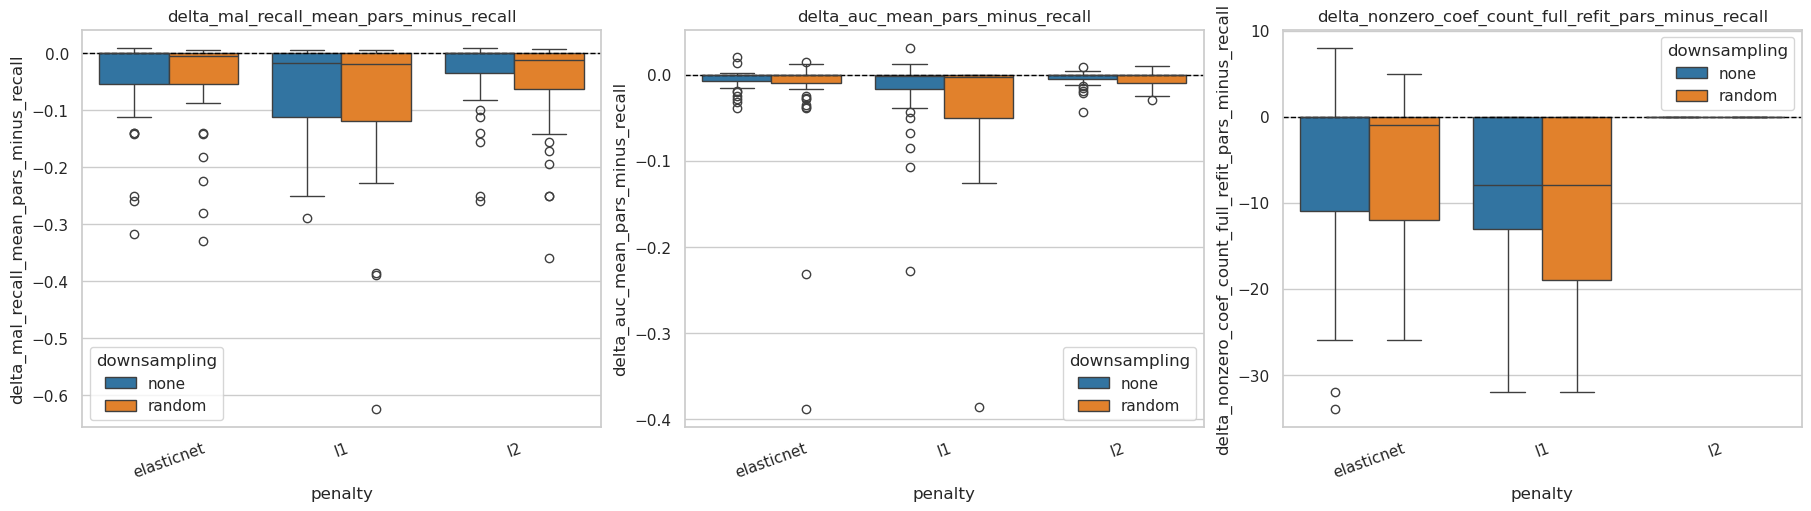

In [16]:
# Strategy comparison and aggregate summaries across patients
cmp_strategy = selected_recall.merge(
    selected_pars,
    on=["patient", "method", "downsampling", "penalty"],
    suffixes=("_recall", "_pars"),
)

for m in ["mal_recall_mean", "auc_mean", "ap_mean", "acc_mean", "nonzero_coef_count_full_refit", "selected_alpha"]:
    cmp_strategy[f"delta_{m}_pars_minus_recall"] = cmp_strategy[f"{m}_pars"] - cmp_strategy[f"{m}_recall"]

cmp_path = per_patient_out / "per_patient_strategy_comparison_recall_vs_most_parsimonious.csv"
cmp_strategy.to_csv(cmp_path, index=False)
print("Saved strategy comparison:", cmp_path)

display(cmp_strategy.head())

summary_metrics = (
    pd.concat([selected_recall, selected_pars], ignore_index=True)
    .groupby(["strategy", "method", "downsampling", "penalty"], observed=False)
    [["mal_recall_mean", "auc_mean", "ap_mean", "acc_mean", "nonzero_coef_count_full_refit", "selected_alpha"]]
    .agg(["mean", "std", "median"])
)
summary_metrics.columns = [f"{a}_{b}" for a, b in summary_metrics.columns]
summary_metrics = summary_metrics.reset_index()
summary_path = per_patient_out / "per_patient_summary_metrics_by_combo.csv"
summary_metrics.to_csv(summary_path, index=False)
print("Saved summary metrics:", summary_path)

display(summary_metrics.head())

# Distribution plots of key deltas by method/penalty
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
for ax, col in zip(
    axes,
    [
        "delta_mal_recall_mean_pars_minus_recall",
        "delta_auc_mean_pars_minus_recall",
        "delta_nonzero_coef_count_full_refit_pars_minus_recall",
    ],
):
    sns.boxplot(data=cmp_strategy, x="penalty", y=col, hue="downsampling", ax=ax)
    ax.axhline(0, color="black", lw=1, linestyle="--")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=20)

plt.show()

In [17]:
def _first_existing_path(candidates: list[Path], label: str) -> Path:
    for p in candidates:
        if p.exists():
            return p
    searched = "\n".join([f" - {p}" for p in candidates])
    raise FileNotFoundError(f"Could not find {label}. Tried:\n{searched}")


def get_gene_names(exp_dir: Path, k: int = 40) -> pd.Index:
    ad_path = _first_existing_path(
        [
            exp_dir / "preprocessing" / f"adata_processed_with_plan0_dr_k{k}_seed1.h5ad",
            exp_dir / "preprocessing" / "adata_processed_with_plan0_dr.h5ad",
            exp_dir / "preprocessing" / "adata_processed.h5ad",
        ],
        label="gene reference h5ad",
    )
    ad = sc.read_h5ad(ad_path, backed="r")
    genes = ad.var_names.copy()
    del ad
    return genes


def load_df_npz(path: Path) -> pd.DataFrame:
    d = np.load(path, allow_pickle=True)
    values = d["values"]
    index = d["index"]
    columns = d["columns"]
    return pd.DataFrame(values, index=index, columns=columns)


def load_gene_loadings(exp_dir: Path, method: str, k: int = 40) -> pd.DataFrame:
    if method in {"fa", "factosig"}:
        adk_path = _first_existing_path(
            [
                exp_dir / "preprocessing" / f"adata_processed_with_plan0_dr_k{k}_seed1.h5ad",
                exp_dir / "preprocessing" / "adata_processed_with_plan0_dr.h5ad",
                exp_dir / "preprocessing" / "adata_processed.h5ad",
            ],
            label=f"{method} loading source h5ad",
        )
        adk = sc.read_h5ad(adk_path, backed="r")
        key = "FA_loadings" if method == "fa" else "FACTOSIG_loadings"
        L = np.asarray(adk.varm[key])
        genes = adk.var_names.copy()
        cols = [f"{method}_{i+1}" for i in range(L.shape[1])]
        out = pd.DataFrame(L, index=genes, columns=cols)
        del adk
        return out

    if method in {"pca", "factosig_promax"}:
        genes = get_gene_names(exp_dir, k=k)
        p = exp_dir / "analysis" / "plan0" / "stability" / method / f"k_{k}" / "replicates" / "seed_1" / "loadings.npy"
        if not p.exists():
            raise FileNotFoundError(f"Missing loadings file: {p}")
        L = np.load(p)
        cols = [f"{method}_{i+1}" for i in range(L.shape[1])]
        return pd.DataFrame(L, index=genes, columns=cols)

    if method == "cnmf":
        p = exp_dir / "models" / "cnmf_plan0" / "curated" / f"k_{k}" / "consensus" / f"plan0_cnmf.spectra.k_{k}.dt_0_5.consensus.df.npz"
        if not p.exists():
            raise FileNotFoundError(f"Missing cNMF spectra file: {p}")
        S = load_df_npz(p)
        L = S.T.copy()
        L.columns = L.columns.astype(str)
        return L

    raise ValueError(f"Unsupported method: {method}")


def coef_vector_at_selected_point(coef_df: pd.DataFrame, alpha: float, l1_ratio: float | None) -> pd.Series:
    c = coef_df.copy()
    c = c[np.isclose(c["alpha"], alpha, atol=1e-12)]

    if "l1_ratio" in c.columns:
        if l1_ratio is None or np.isnan(l1_ratio):
            c = c[c["l1_ratio"].isna()]
        else:
            c = c[np.isclose(c["l1_ratio"], l1_ratio, atol=1e-12)]

    if c.empty:
        raise ValueError("No coefficient rows found for selected alpha/l1_ratio")

    w = c.groupby("feature", observed=False)["coef"].mean()
    w.index = w.index.astype(str)
    return w


def build_selected_signatures_per_patient(selected_df: pd.DataFrame, exp_dir: Path, k: int = 40) -> pd.DataFrame:
    method_loadings: dict[str, pd.DataFrame] = {}
    signatures = {}

    for _, r in selected_df.iterrows():
        method = r["method"]
        if method not in method_loadings:
            method_loadings[method] = load_gene_loadings(exp_dir, method, k=k)

        L = method_loadings[method].copy()
        L.columns = L.columns.astype(str)

        coef_df = pd.read_csv(r["coef_path"])
        w = coef_vector_at_selected_point(coef_df, alpha=r["selected_alpha"], l1_ratio=r["selected_l1_ratio"])
        w = w.reindex(L.columns).fillna(0.0)

        s = L.values @ w.values
        model_id = f"{r['strategy']}|{r['patient']}|{method}|{r['downsampling']}|{r['penalty']}"
        signatures[model_id] = pd.Series(s, index=L.index)

    return pd.DataFrame(signatures)


def cosine_similarity_matrix(X: pd.DataFrame) -> pd.DataFrame:
    A = X.values
    denom = np.linalg.norm(A, axis=0, keepdims=True)
    denom[denom == 0] = 1.0
    A_norm = A / denom
    sim = A_norm.T @ A_norm
    return pd.DataFrame(sim, index=X.columns, columns=X.columns)


def jaccard_matrix(sets_by_name: dict[str, set]) -> pd.DataFrame:
    names = list(sets_by_name.keys())
    out = pd.DataFrame(index=names, columns=names, dtype=float)
    for a in names:
        for b in names:
            A, B = sets_by_name[a], sets_by_name[b]
            u = len(A | B)
            out.loc[a, b] = len(A & B) / u if u > 0 else np.nan
    return out


# Build signatures for all per-patient selected models (both strategies)
selected_all = pd.concat([selected_recall, selected_pars], ignore_index=True)
sig_df_pp = build_selected_signatures_per_patient(selected_all, EXP_DIR, k=K_FIXED)
print("Signature matrix shape (genes x selected per-patient models):", sig_df_pp.shape)

sig_out = OUTPUT_DIR / "per_patient_signatures"
sig_out.mkdir(parents=True, exist_ok=True)

# Save wide signatures to parquet (better for large matrix)
sig_df_pp.to_parquet(sig_out / "per_patient_selected_signatures.parquet")

# Per-patient similarity/Jaccard plots and matrices
TOP_N = 200
for patient, sub in selected_all.groupby("patient", observed=False):
    model_cols = [
        f"{r['strategy']}|{r['patient']}|{r['method']}|{r['downsampling']}|{r['penalty']}"
        for _, r in sub.iterrows()
    ]
    model_cols = [c for c in model_cols if c in sig_df_pp.columns]
    if not model_cols:
        continue

    sig_sub = sig_df_pp[model_cols]
    cos_sim = cosine_similarity_matrix(sig_sub)
    pearson_sim = sig_sub.corr(method="pearson")

    pos_sets = {name: set(sig_sub[name].nlargest(TOP_N).index.astype(str)) for name in sig_sub.columns}
    neg_sets = {name: set(sig_sub[name].nsmallest(TOP_N).index.astype(str)) for name in sig_sub.columns}
    pos_j = jaccard_matrix(pos_sets)
    neg_j = jaccard_matrix(neg_sets)

    patient_dir = sig_out / str(patient)
    patient_dir.mkdir(parents=True, exist_ok=True)

    cos_sim.to_csv(patient_dir / "cosine_similarity.csv")
    pearson_sim.to_csv(patient_dir / "pearson_similarity.csv")
    pos_j.to_csv(patient_dir / f"top{TOP_N}_positive_gene_jaccard.csv")
    neg_j.to_csv(patient_dir / f"top{TOP_N}_negative_gene_jaccard.csv")

    fig, axes = plt.subplots(2, 2, figsize=(20, 16), constrained_layout=True)
    sns.heatmap(cos_sim, cmap="vlag", center=0, xticklabels=1, yticklabels=1, ax=axes[0, 0])
    axes[0, 0].set_title(f"{patient}: cosine similarity")
    sns.heatmap(pearson_sim, cmap="vlag", center=0, xticklabels=1, yticklabels=1, ax=axes[0, 1])
    axes[0, 1].set_title(f"{patient}: Pearson correlation")
    sns.heatmap(pos_j, cmap="YlGnBu", vmin=0, vmax=1, xticklabels=1, yticklabels=1, ax=axes[1, 0])
    axes[1, 0].set_title(f"{patient}: top+{TOP_N} Jaccard")
    sns.heatmap(neg_j, cmap="YlOrBr", vmin=0, vmax=1, xticklabels=1, yticklabels=1, ax=axes[1, 1])
    axes[1, 1].set_title(f"{patient}: top-{TOP_N} Jaccard")

    for ax in axes.ravel():
        ax.tick_params(axis="x", labelrotation=90, labelsize=7)
        ax.tick_params(axis="y", labelsize=7)

    fig.savefig(patient_dir / "similarity_and_jaccard_heatmaps.png", dpi=160)
    plt.close(fig)

print("Saved per-patient signature outputs to:", sig_out)

KeyError: 'values is not a file in the archive'

In [ ]:
# Optional: Hallmark GSEA per selected per-patient model
RUN_GSEA = False
GSEA_THREADS = int(os.environ.get("GSEA_THREADS", "4"))
GSEA_PERM = int(os.environ.get("GSEA_PERM", "200"))
GSEA_MIN_SIZE = int(os.environ.get("GSEA_MIN_SIZE", "15"))
GSEA_MAX_SIZE = int(os.environ.get("GSEA_MAX_SIZE", "500"))

try:
    import gseapy as gp
except Exception:
    gp = None
    if RUN_GSEA:
        raise RuntimeError("gseapy not installed. Install with: pip install gseapy")


def _safe_name(x: str) -> str:
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(x)).strip("_")


def _resolve_hallmark_gmt() -> Optional[Path]:
    env_path = os.environ.get("HALLMARK_GMT", "").strip()
    if env_path:
        p = Path(env_path)
        if p.exists():
            return p

    candidates = [
        Path("/home/minhang/mds_project/data/cohort_adata/gene_sets/h.all.v2024.1.Hs.symbols.gmt"),
        Path("data/msigdb/h.all.v2023.2.Hs.symbols.gmt"),
        Path("data/msigdb/h.all.v2023.1.Hs.symbols.gmt"),
        Path("data/msigdb/h.all.v7.5.1.symbols.gmt"),
    ]
    for p in candidates:
        if p.exists():
            return p

    hits = sorted(Path(".").rglob("h.all*.gmt"))
    return hits[0] if hits else None


def run_or_read_prerank(series: pd.Series, gene_sets: Path, out_dir: Path) -> Optional[pd.DataFrame]:
    out_dir.mkdir(parents=True, exist_ok=True)

    report_candidates = [
        out_dir / "gseapy.gene_set.prerank.report.csv",
        out_dir / "gseapy.prerank.gene_sets.report.csv",
    ]
    for report_csv in report_candidates:
        if report_csv.exists():
            try:
                return pd.read_csv(report_csv, sep="\t")
            except Exception:
                return pd.read_csv(report_csv)

    if gp is None:
        return None

    rank_df = series.reset_index()
    rank_df.columns = ["gene", "score"]

    res = gp.prerank(
        rnk=rank_df,
        gene_sets=str(gene_sets),
        threads=GSEA_THREADS,
        permutation_num=GSEA_PERM,
        outdir=str(out_dir),
        seed=0,
        min_size=GSEA_MIN_SIZE,
        max_size=GSEA_MAX_SIZE,
        no_plot=True,
        format="png",
        verbose=False,
    )
    return res.res2d.copy()


if RUN_GSEA:
    hallmark_gmt = _resolve_hallmark_gmt()
    if hallmark_gmt is None:
        raise FileNotFoundError("No Hallmark GMT found. Set HALLMARK_GMT env var or add h.all*.gmt")

    print("Using Hallmark GMT:", hallmark_gmt)

    gsea_root = OUTPUT_DIR / "per_patient_hallmark_gsea"
    gsea_root.mkdir(parents=True, exist_ok=True)

    rows = []
    for model_uid in sig_df_pp.columns:
        strategy, patient, method, downsampling, penalty = model_uid.split("|", maxsplit=4)
        rank = sig_df_pp[model_uid].sort_values(ascending=False)

        out_dir = gsea_root / _safe_name(patient) / _safe_name(strategy) / _safe_name(f"{method}|{downsampling}|{penalty}")
        df = run_or_read_prerank(rank, hallmark_gmt, out_dir)
        if df is None or df.empty:
            continue

        fdr_col = next((c for c in ["FDR q-val", "fdr", "fdr_q-val", "fdr_q_value"] if c in df.columns), None)
        nes_col = next((c for c in ["NES", "nes"] if c in df.columns), None)
        term_col = next((c for c in ["Term", "term", "NAME", "name"] if c in df.columns), None)

        fdr_num = pd.to_numeric(df[fdr_col], errors="coerce") if fdr_col is not None else pd.Series(np.nan, index=df.index)
        n_sig = int((fdr_num < 0.05).sum()) if fdr_col is not None else np.nan

        rows.append(
            {
                "model_uid": model_uid,
                "strategy": strategy,
                "patient": patient,
                "method": method,
                "downsampling": downsampling,
                "penalty": penalty,
                "n_sig_pathways_fdr_lt_0p05": n_sig,
            }
        )

        if nes_col is not None and term_col is not None:
            nes_df = pd.DataFrame({"term": df[term_col], "NES": pd.to_numeric(df[nes_col], errors="coerce")}).dropna(subset=["NES"])
            top_pos = nes_df.nlargest(8, "NES")
            top_neg = nes_df.nsmallest(8, "NES")
            plot_df = pd.concat([top_neg, top_pos], ignore_index=True).sort_values("NES")

            if not plot_df.empty:
                fig, ax = plt.subplots(figsize=(10, 6))
                colors = np.where(plot_df["NES"] >= 0, "#b2182b", "#2166ac")
                ax.barh(plot_df["term"], plot_df["NES"], color=colors)
                ax.axvline(0, color="black", lw=1)
                ax.set_title(f"NES: {model_uid}")
                ax.set_xlabel("Normalized Enrichment Score (NES)")
                plt.tight_layout()
                fig.savefig(out_dir / "nes_top_pos_neg_barplot.png", dpi=160)
                plt.close(fig)

    gsea_counts = pd.DataFrame(rows).sort_values(["patient", "strategy", "method", "downsampling", "penalty"])
    gsea_counts.to_csv(gsea_root / "hallmark_gsea_counts_per_selected_model.csv", index=False)
    print("Saved GSEA outputs to:", gsea_root)
    display(gsea_counts.head())
else:
    print("RUN_GSEA is False. Set RUN_GSEA=True to run Hallmark GSEA exports.")

RUN_GSEA is False. Set RUN_GSEA=True to run Hallmark GSEA exports.
